<a href="https://colab.research.google.com/github/shravani-jagdale-2006/linear-regression-advertising/blob/main/LR_Advertising_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Advertising Budget and Sales.csv to Advertising Budget and Sales.csv


In [4]:
df = pd.read_csv("Advertising Budget and Sales.csv")

In [7]:
df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [10]:
df.isnull().sum()

,0
TV Ad Budget ($),0
Radio Ad Budget ($),0
Newspaper Ad Budget ($),0
Sales ($),0


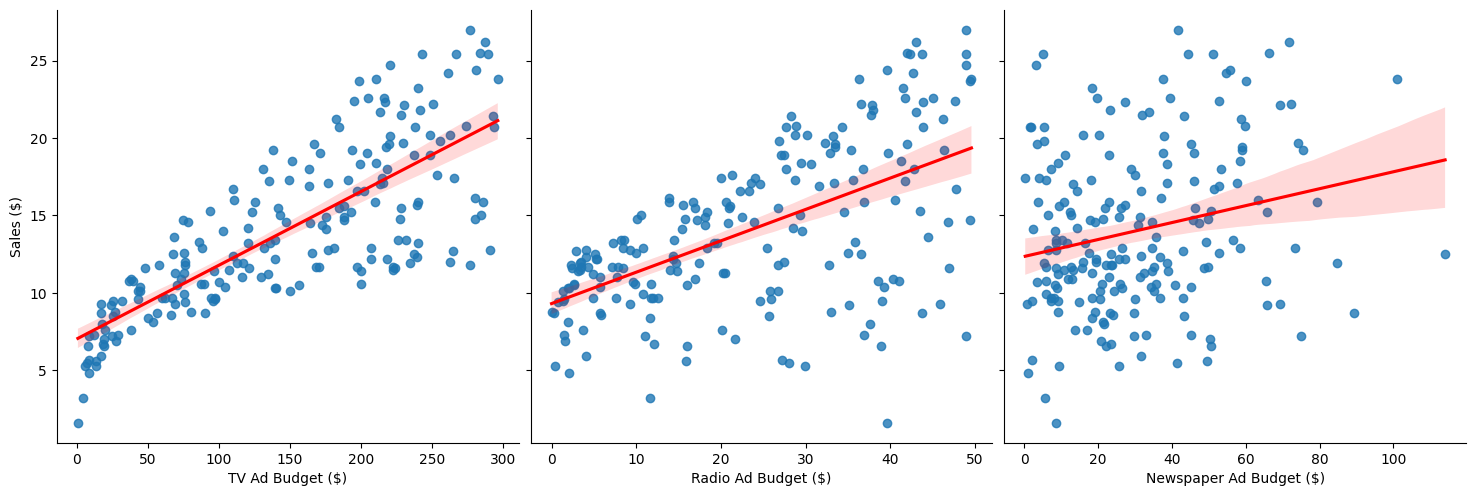

In [28]:

sns.pairplot(
    df,
    x_vars=["TV Ad Budget ($)", "Radio Ad Budget ($)", "Newspaper Ad Budget ($)"],
    y_vars=["Sales ($)"],
    height=5,
    kind="reg",
    plot_kws={"line_kws": {"color": "red"}}

)
plt.show()

In [29]:
X=df.drop(columns=["Sales ($)"])
y=df["Sales ($)"]

In [32]:
# train test split for model

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [37]:
# train model

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [38]:
# predict values
y_predict = model.predict(X_test)

In [39]:
y_predict

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967,
        9.04831992,  6.65328312, 14.34554487,  8.90349333,  9.68959028,
       12.16494386,  8.73628397, 16.26507258, 10.27759582, 18.83109103,
       19.56036653, 13.25103464, 12.33620695, 21.30695132,  7.82740305,
        5.80957448, 20.75753231, 11.98138077,  9.18349576,  8.5066991 ,
       12.46646769, 10.00337695, 21.3876709 , 12.24966368, 18.26661538,
       20.13766267, 14.05514005, 20.85411186, 11.0174441 ,  4.56899622])

In [41]:
y_test.head()

,Sales ($)
95,16.9
15,22.4
30,21.4
158,7.3
128,24.7


In [46]:
# Evaluate for model
from sklearn.metrics import r2_score
r = r2_score(y_test, y_predict)
print("r-squared value: ", r)

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r = 1 - ((1 - r) * (n - 1) / (n - p - 1))
print("adjusted r-squared value: ", adjusted_r)

r-squared value:  0.899438024100912
adjusted r-squared value:  0.8910578594426547
